Convert number density to corresponding halo mass

In [1]:
import numpy as np
import eplots
import hmf

In [2]:
z = 0
h = 0.7 # Set the reduced hubble parameter to 0.7
my_hmf = hmf.hmf.MassFunction(Mmin = 5, Mmax = 14, dlog10m = .1, hmf_model = 'ST', z = z)

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/hmf/density_field/transfer_models.py:233: UserWarning: 'extrapolate_with_eh' was not set. Defaulting to True, which is different behaviour than versions <=3.4.4. This warning may be removed in v4.0. Silence it by setting extrapolate_with_eh explicitly.
  warnings.warn(


Text(0.5, 0, '$M_{\\rm{halo}}$ / $M_{\\odot}$')

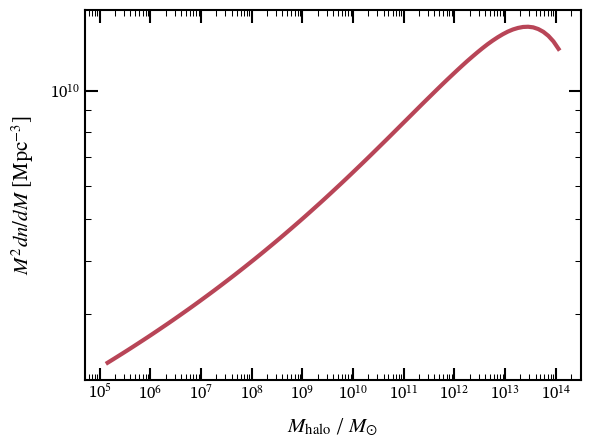

In [8]:
fig, ax = plt.subplots()
ax.loglog(my_hmf.m/h, my_hmf.dndm/h**3*my_hmf.m**2)
ax.set_ylabel(r'$M^2 dn/dM$ [Mpc$^{-3}$]')
ax.set_xlabel(r'$M_{\rm{halo}}$ / $M_{\odot}$')

Text(0.5, 1.0, 'Cumulative HMF, $z=0$')

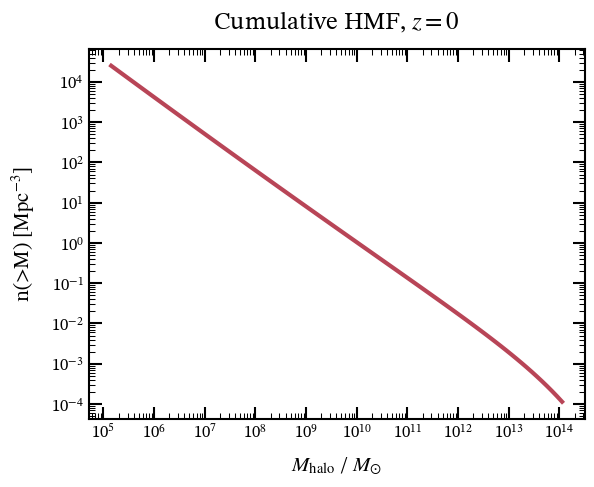

In [9]:
fig, ax = plt.subplots()
ax.loglog(my_hmf.m/h, my_hmf.ngtm/h**3)
ax.set_ylabel(r'n(>M) [$\rm{Mpc}^{-3}$]')
ax.set_xlabel(r'$M_{\rm{halo}}$ / $M_{\odot}$')
ax.set_title(f'Cumulative HMF, $z={z}$')

In [13]:
def n_to_M(hmf_class, n_target, h = 0.7):
    chmf = hmf_class.ngtm/h**3 # cumulative halo mass function
    
    if all(chmf > n_target):
        raise Exception('The halo mass corresponding to that number density is larger than your mass range')
    elif all(chmf < n_target):
        raise Exception('The halo mass corresponding to that number density is smaller than your mass range')

    return hmf_class.m[np.argsort(np.abs(chmf - n_target))[0]]/h

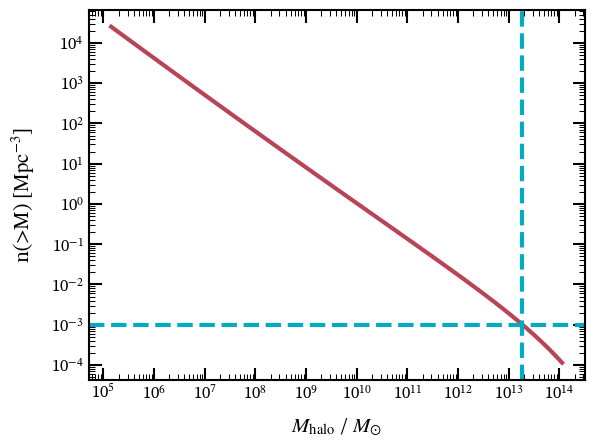

In [23]:
n = 1e-3
fig, ax = plt.subplots()
ax.loglog(my_hmf.m/h, my_hmf.ngtm/h**3)
ax.set_ylabel(r'n(>M) [$\rm{Mpc}^{-3}$]')
ax.set_xlabel(r'$M_{\rm{halo}}$ / $M_{\odot}$')
ax.axhline(n, color = '#03abc1', linestyle = 'dashed')
target_mass = n_to_M(my_hmf, n)
ax.axvline(target_mass, color = '#03abc1', linestyle = 'dashed')

In [6]:
np.log10(target_mass)

12.099999999999975

#b84557
#03abc1
#d4d000
#294450
#bf5700
#719920
#8aa0ff


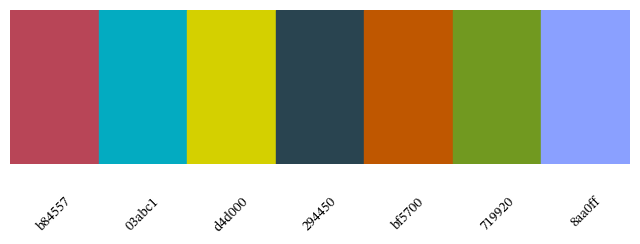

In [7]:
eplots.plot_colors()

Text(0.5, 1.0, 'SMHM relation for $z = 7-11$ galaxies')

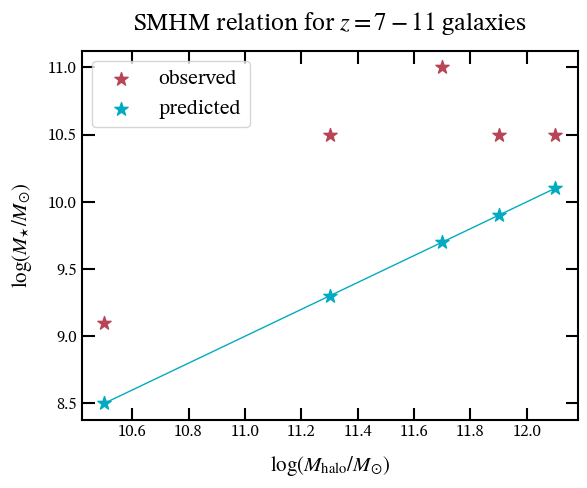

In [38]:
log_halo_masses = np.array([10.5, 11.3, 11.7, 11.9, 12.1])
log_stellar_masses = np.array([9.1, 10.5, 11, 10.5, 10.5])
names = ['GN-z11', 'Professor C', 'Mahan', 'S6209', 'N9094']
predicted_stellar_masses = log_halo_masses-2 # Divide by 100 = subtract 2 from log

fig, ax = plt.subplots()
ax.scatter(log_halo_masses, log_stellar_masses, color = '#b84557', marker = '*', s = 100, label = 'observed')
ax.scatter(log_halo_masses, predicted_stellar_masses, color = '#03abc1', marker = '*', s = 100, label = r'predicted')
ax.plot(log_halo_masses, predicted_stellar_masses, color = '#03abc1', linewidth = 1)
ax.legend()
ax.set_ylabel(r'$\log(M_{\star}/M_{\odot})$')
ax.set_xlabel(r'$\log(M_{\rm{halo}}/M_{\odot})$')
ax.set_title(r'SMHM relation for $z = 7-11$ galaxies')

In [238]:
np.log10(3e10)

10.477121254719663